#**Business Problem Statement**
###With the rapid growth of mobile applications, companies receive thousands of user reviews daily. Manually analyzing this feedback is inefficient and time-consuming.
###The objective of this project is to build a Machine Learning system that automatically classifies app reviews into Positive and Negative sentiments.
###Additionally, the project aims to identify high-risk applications by analyzing the percentage of negative reviews, enabling data-driven product improvement decisions.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#**Data Understanding**

###The dataset contains 200,000 Google Play Store reviews across 20 different applications.
###Columns included:
1. ReviewId - Unique identifier of the reviewList item
2. Content - Review text
3. score - User rating (1-5)
4. app - Application name

###Since sentiment can be derived from ratings, we converted ratings into binary labels:

*  1-2 → Negative
*  4-5 → Positive
*  3 → Neutral (removed for strategic clarity)

###The dataset showed class imbalance, with positive reviews significantly higher than negative ones.

In [ ]:
rev = pd.read_csv('/content/drive/MyDrive/Intelligent App Review Analysis & Sentiment Classification System/all_combined.csv')
rev.head()

,reviewId,content,score,app
0,8ff5d701-5add-4f1d-b2bb-bb8c62756c8f,nice,4,Facebook
1,8d65d11f-506f-4714-aa75-8d21d0e01629,super,5,Facebook
2,8f0804ab-7b36-46d9-9af8-61b5b02b3e72,fun,4,Facebook
3,a2d7f723-e1e0-4555-bc5c-8ebe214feb86,Waste of time. Spend your time living and dele...,1,Facebook
4,09270a5d-4428-47dc-9471-a8f01f022dbc,super super app,5,Facebook


In [ ]:
rev.columns

Index(['reviewId', 'content', 'score', 'app'], dtype='object')

In [ ]:
rev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   reviewId  200000 non-null  object
 1   content   199980 non-null  object
 2   score     200000 non-null  int64 
 3   app       200000 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.1+ MB


**Data Preprocessing**

To prepare text data for modeling:

*  Removed missing values
*  Converted ratings into binary sentiment labels
* Removed neutral reviews
* Cleaned text (lowercasing, removing punctuation, stopwords)

In [ ]:
rev = rev.dropna(subset=['content'])
rev.shape

(199980, 4)

In [ ]:
rev = rev.dropna(subset=['content'])
rev.shape

,count
sentiment,
Positive,138535
Negative,51401
Neutral,10044


In [ ]:
rev["sentiment"].value_counts(normalize=True) * 100

,proportion
sentiment,
Positive,69.274427
Negative,25.703070
Neutral,5.022502


In [ ]:
rev["app"].nunique()

20

In [ ]:
# TOP APPS BY REVIEW COUNT

rev["app"].value_counts().head(10)

,count
app,
Facebook,10000
WhatsApp,10000
Instagram,10000
Subway Surfers,10000
SHAREit,10000
Facebook Lite,10000
Snapchat,10000
Microsoft PowerPoint,10000
Spotify,10000


##Neutral reviews were only 5%, so I excluded them to reduce class imbalance and improve model reliability

In [ ]:
rev = rev[rev["sentiment"] != "Neutral"]
rev["sentiment"].value_counts(normalize=True) * 100

,proportion
sentiment,
Positive,72.937726
Negative,27.062274


In [ ]:
rev["label"] = rev["sentiment"].map({"Negative": 0,"Positive": 1})

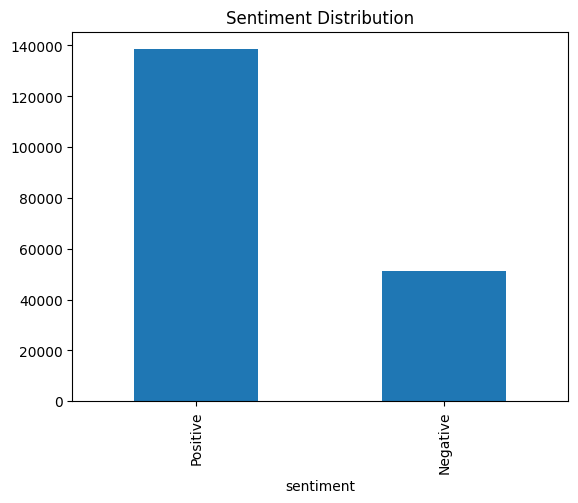

In [ ]:
import matplotlib.pyplot as plt
rev["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
import re
def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove numbers & special characters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

rev["cleaned_review"] = rev["content"].apply(clean_text)
rev[["content", "cleaned_review"]].head()

# I removed URLs, special characters, and normalized text to lowercase before vectorization.

,content,cleaned_review
0,nice,nice
1,super,super
2,fun,fun
3,Waste of time. Spend your time living and dele...,waste of time spend your time living and delet...
4,super super app,super super app


###Train-Test Split on Cleaned Text

In [ ]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(rev["cleaned_review"],rev["label"],test_size=0.2,random_state=42,stratify=rev["label"])

#**Feature Engineering** - TF-IDF

###Machine learning models require numerical input.

###We used TF-IDF to convert review text into numerical features.

###TF-IDF assigns higher importance to words that are frequent in a review but rare across the dataset, helping the model focus on meaningful words.

###We limited features to 10,000 to reduce overfitting and improve computational efficiency.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline_lr = Pipeline([("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
    ("model", LogisticRegression(max_iter=1000))])

In [ ]:
pipeline_lr.fit(X_train_text, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, stop_words='english')),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred = pipeline_lr.predict(X_test_text)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Recall 0.74 Model is missing some negative reviews.

Accuracy: 0.8954669895756555
              precision    recall  f1-score   support

           0       0.85      0.74      0.79     10280
           1       0.91      0.95      0.93     27708

    accuracy                           0.90     37988
   macro avg       0.88      0.85      0.86     37988
weighted avg       0.89      0.90      0.89     37988



##Since the dataset was imbalanced, class weighting was applied to improve performance on the minority (negative) class.

In [ ]:
pipeline_lr2 = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])

pipeline_lr2.fit(X_train_text, y_train)
y_pred_lr2 = pipeline_lr2.predict(X_test_text)

print("Logistic (Balanced) Accuracy:", accuracy_score(y_test, y_pred_lr2))
print(classification_report(y_test, y_pred_lr2))

Logistic (Balanced) Accuracy: 0.8865431188796462
              precision    recall  f1-score   support

           0       0.76      0.84      0.80     10280
           1       0.94      0.90      0.92     27708

    accuracy                           0.89     37988
   macro avg       0.85      0.87      0.86     37988
weighted avg       0.89      0.89      0.89     37988



In [ ]:
# LINEAR SVM

from sklearn.svm import LinearSVC

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
    ("model", LinearSVC(class_weight="balanced"))])

pipeline_svm.fit(X_train_text, y_train)
y_pred_svm = pipeline_svm.predict(X_test_text)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8847004317152785
              precision    recall  f1-score   support

           0       0.77      0.82      0.79     10280
           1       0.93      0.91      0.92     27708

    accuracy                           0.88     37988
   macro avg       0.85      0.87      0.86     37988
weighted avg       0.89      0.88      0.89     37988



## **Balanced Logistic Regression gives the best result**
## It improved negative recall from 0.74 To 0.84

In [ ]:
#“Although the baseline model had slightly higher accuracy, the balanced logistic regression improved recall for negative reviews significantly.
#Since detecting dissatisfied users is more critical for business, I selected the balanced model despite a minor drop in overall accuracy.”

#**Model Interpretation**

###To understand model behavior, we analyzed the most influential words using model coefficients.

###Positive coefficients indicate strong association with positive sentiment, while negative coefficients indicate association with negative sentiment.

###The extracted words aligned well with intuitive emotional expressions, validating the model’s learning process.

In [ ]:
# Feature Names
feature_names = pipeline_lr2.named_steps["tfidf"].get_feature_names_out()

In [ ]:
# Model Coefficient
coefficients = pipeline_lr2.named_steps["model"].coef_[0]

In [ ]:
import numpy as np

top_positive = np.argsort(coefficients)[-20:]

for index in top_positive:
    print(feature_names[index])

superb
convenient
fantastic
childhood
interesting
outstanding
entertaining
loving
amazing
exceptional
awesome
best
informative
perfect
love
brilliant
fun
great
easy
excellent


In [ ]:
top_negative = np.argsort(coefficients)[:20]

for index in top_negative:
    print(feature_names[index])

worst
useless
stupid
garbage
horrible
terrible
worse
trash
removed
greedy
sucks
uninstalled
deleting
poor
awful
anymore
uninstall
broken
waste
sign


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipeline_lr2,rev["cleaned_review"],rev["label"],cv=5,scoring="f1_macro")

print("Cross Validation F1 Scores:", scores)
print("Average F1 Score:", scores.mean())

Cross Validation F1 Scores: [0.83707624 0.7966267  0.84035786 0.76989997 0.79247946]
Average F1 Score: 0.8072880464101508


In [ ]:
# “The model’s learned coefficients aligned with intuitive sentiment expressions, confirming feature relevance.”

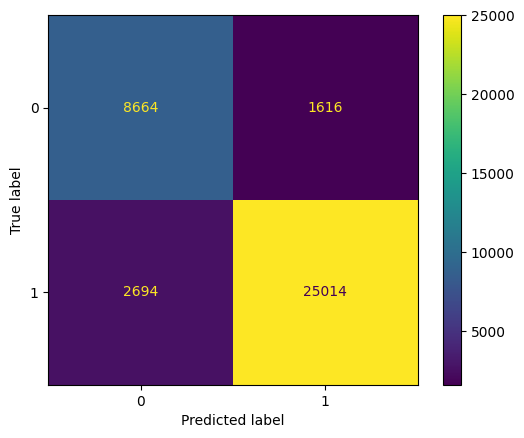

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(pipeline_lr2,X_test_text,y_test)
plt.show()

#**App-Level Business Insights**

###Using predicted sentiments, we calculated the percentage of negative reviews per application.

###This allowed fair comparison across apps regardless of review volume.

###Applications such as LINE and Netflix showed significantly higher negative sentiment percentages, indicating potential areas requiring product improvement.

In [ ]:
# Prediction on full
rev["predicted_sentiment"] = pipeline_lr.predict(rev["cleaned_review"])

In [ ]:
# Calculate % Negative/App
app_analysis = rev.groupby("app")["predicted_sentiment"].value_counts(normalize=True).unstack()

In [ ]:
# Top Risky Apps
app_analysis.columns = ["Negative_Percentage", "Positive_Percentage"]
app_analysis = app_analysis.sort_values(by="Negative_Percentage", ascending=False)

app_analysis.head()

,Negative_Percentage,Positive_Percentage
app,,
LINE,0.549646,0.450354
Netflix,0.468657,0.531343
Flipboard,0.383698,0.616302
Twitter,0.380073,0.619927
Dropbox,0.372068,0.627932


In [ ]:
# “LINE shows significantly higher predicted negative sentiment compared to other apps, indicating potential user dissatisfaction issues.”

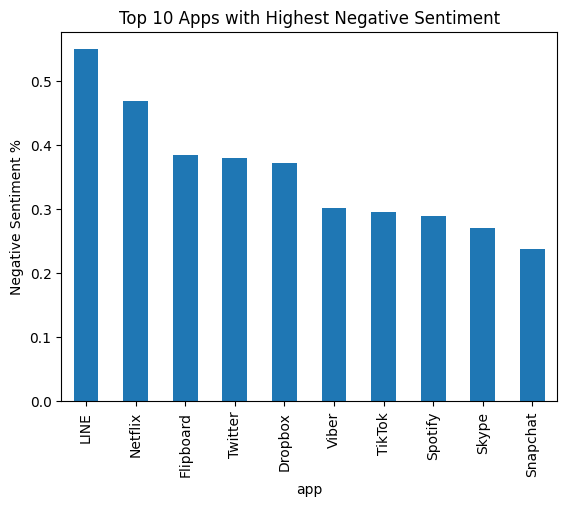

In [ ]:
import matplotlib.pyplot as plt

app_analysis["Negative_Percentage"].head(10).plot(kind="bar")
plt.title("Top 10 Apps with Highest Negative Sentiment")
plt.ylabel("Negative Sentiment %")
plt.show()

##The final model provides a scalable solution for analyzing large-scale user feedback and supporting data-driven product decisions.

#**“This model is ready for deployment using Streamlit for real-time sentiment prediction.”**

In [35]:
import joblib
joblib.dump(pipeline_lr2, "sentiment.pkl")

['sentiment.pkl']

In [36]:
from google.colab import files
files.download("sentiment.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>